# Supplementary: Checking spe-1 patch recordings for a stimulation artifact

**Ashley's comment:** the spe-1 dataset is described as spontaneous activity, but we can't formally rule out that the experimenter delivered stimulation at some points to drive low-firing neurons. Her suggestion for what to look for: *"I think you would see this as a very slight shift in membrane potential unless they had balanced the bridge absolutely perfectly ... you might also see tiny capacitance transients."*

**What this notebook does:** exactly that, and nothing more - for every spe-1 cell, using the **raw, unfiltered** patch recording (not the bandpass-filtered version used elsewhere in the paper, since filtering can hide a slow baseline shift):

1. Plot the resting baseline level across the whole recording, for every cell at a glance - a real shift would show up as a step to a new sustained level.
2. Zoom into a handful of raw-trace snippets for any cell of interest, to look by eye for brief transient blips.

No spike detection, no statistics, no automatic classification - just look at the trace.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../../datasets/spe-1/spe1_helper_modules/')
import config

RAW_PATCH_DIR = os.path.join(config.SPE1_DATA_ROOT, 'raw_patch_recordings')

def load_raw_patch(cell_num):
    """Load a cell's raw, unfiltered patch recording (float64, in the units it was recorded in)."""
    fs = config.DICT_PATCH_FS[cell_num]
    trace = np.fromfile(os.path.join(RAW_PATCH_DIR, f'c{cell_num}_patch_ch1.bin'), dtype='float64')
    return trace, fs

## 1. Does the baseline level shift anywhere during the recording?

For each cell: split the raw recording into 1-second chunks and take the median voltage in each chunk (the median is barely affected by the handful of tall, brief spikes in each chunk, so this line tracks the *resting* level, not the spikes). A steady, if noisy, flat line means no shift. A step up or down to a new sustained level would be exactly the kind of "slight shift in membrane potential" Ashley described.

In [2]:
cell_nums = sorted(int(c[1:]) for c in config.CELL_IDS)

baselines = {}
for cell_num in cell_nums:
    trace, fs = load_raw_patch(cell_num)
    bin_samples = int(1.0 * fs)  # 1-second bins
    n_bins = len(trace) // bin_samples
    chunks = trace[:n_bins * bin_samples].reshape(n_bins, bin_samples)
    baseline = np.median(chunks, axis=1)
    t_min = np.arange(n_bins) / 60.0  # minutes
    baselines[cell_num] = (t_min, baseline)

print(f'Computed baseline traces for {len(baselines)} cells.')

Computed baseline traces for 43 cells.


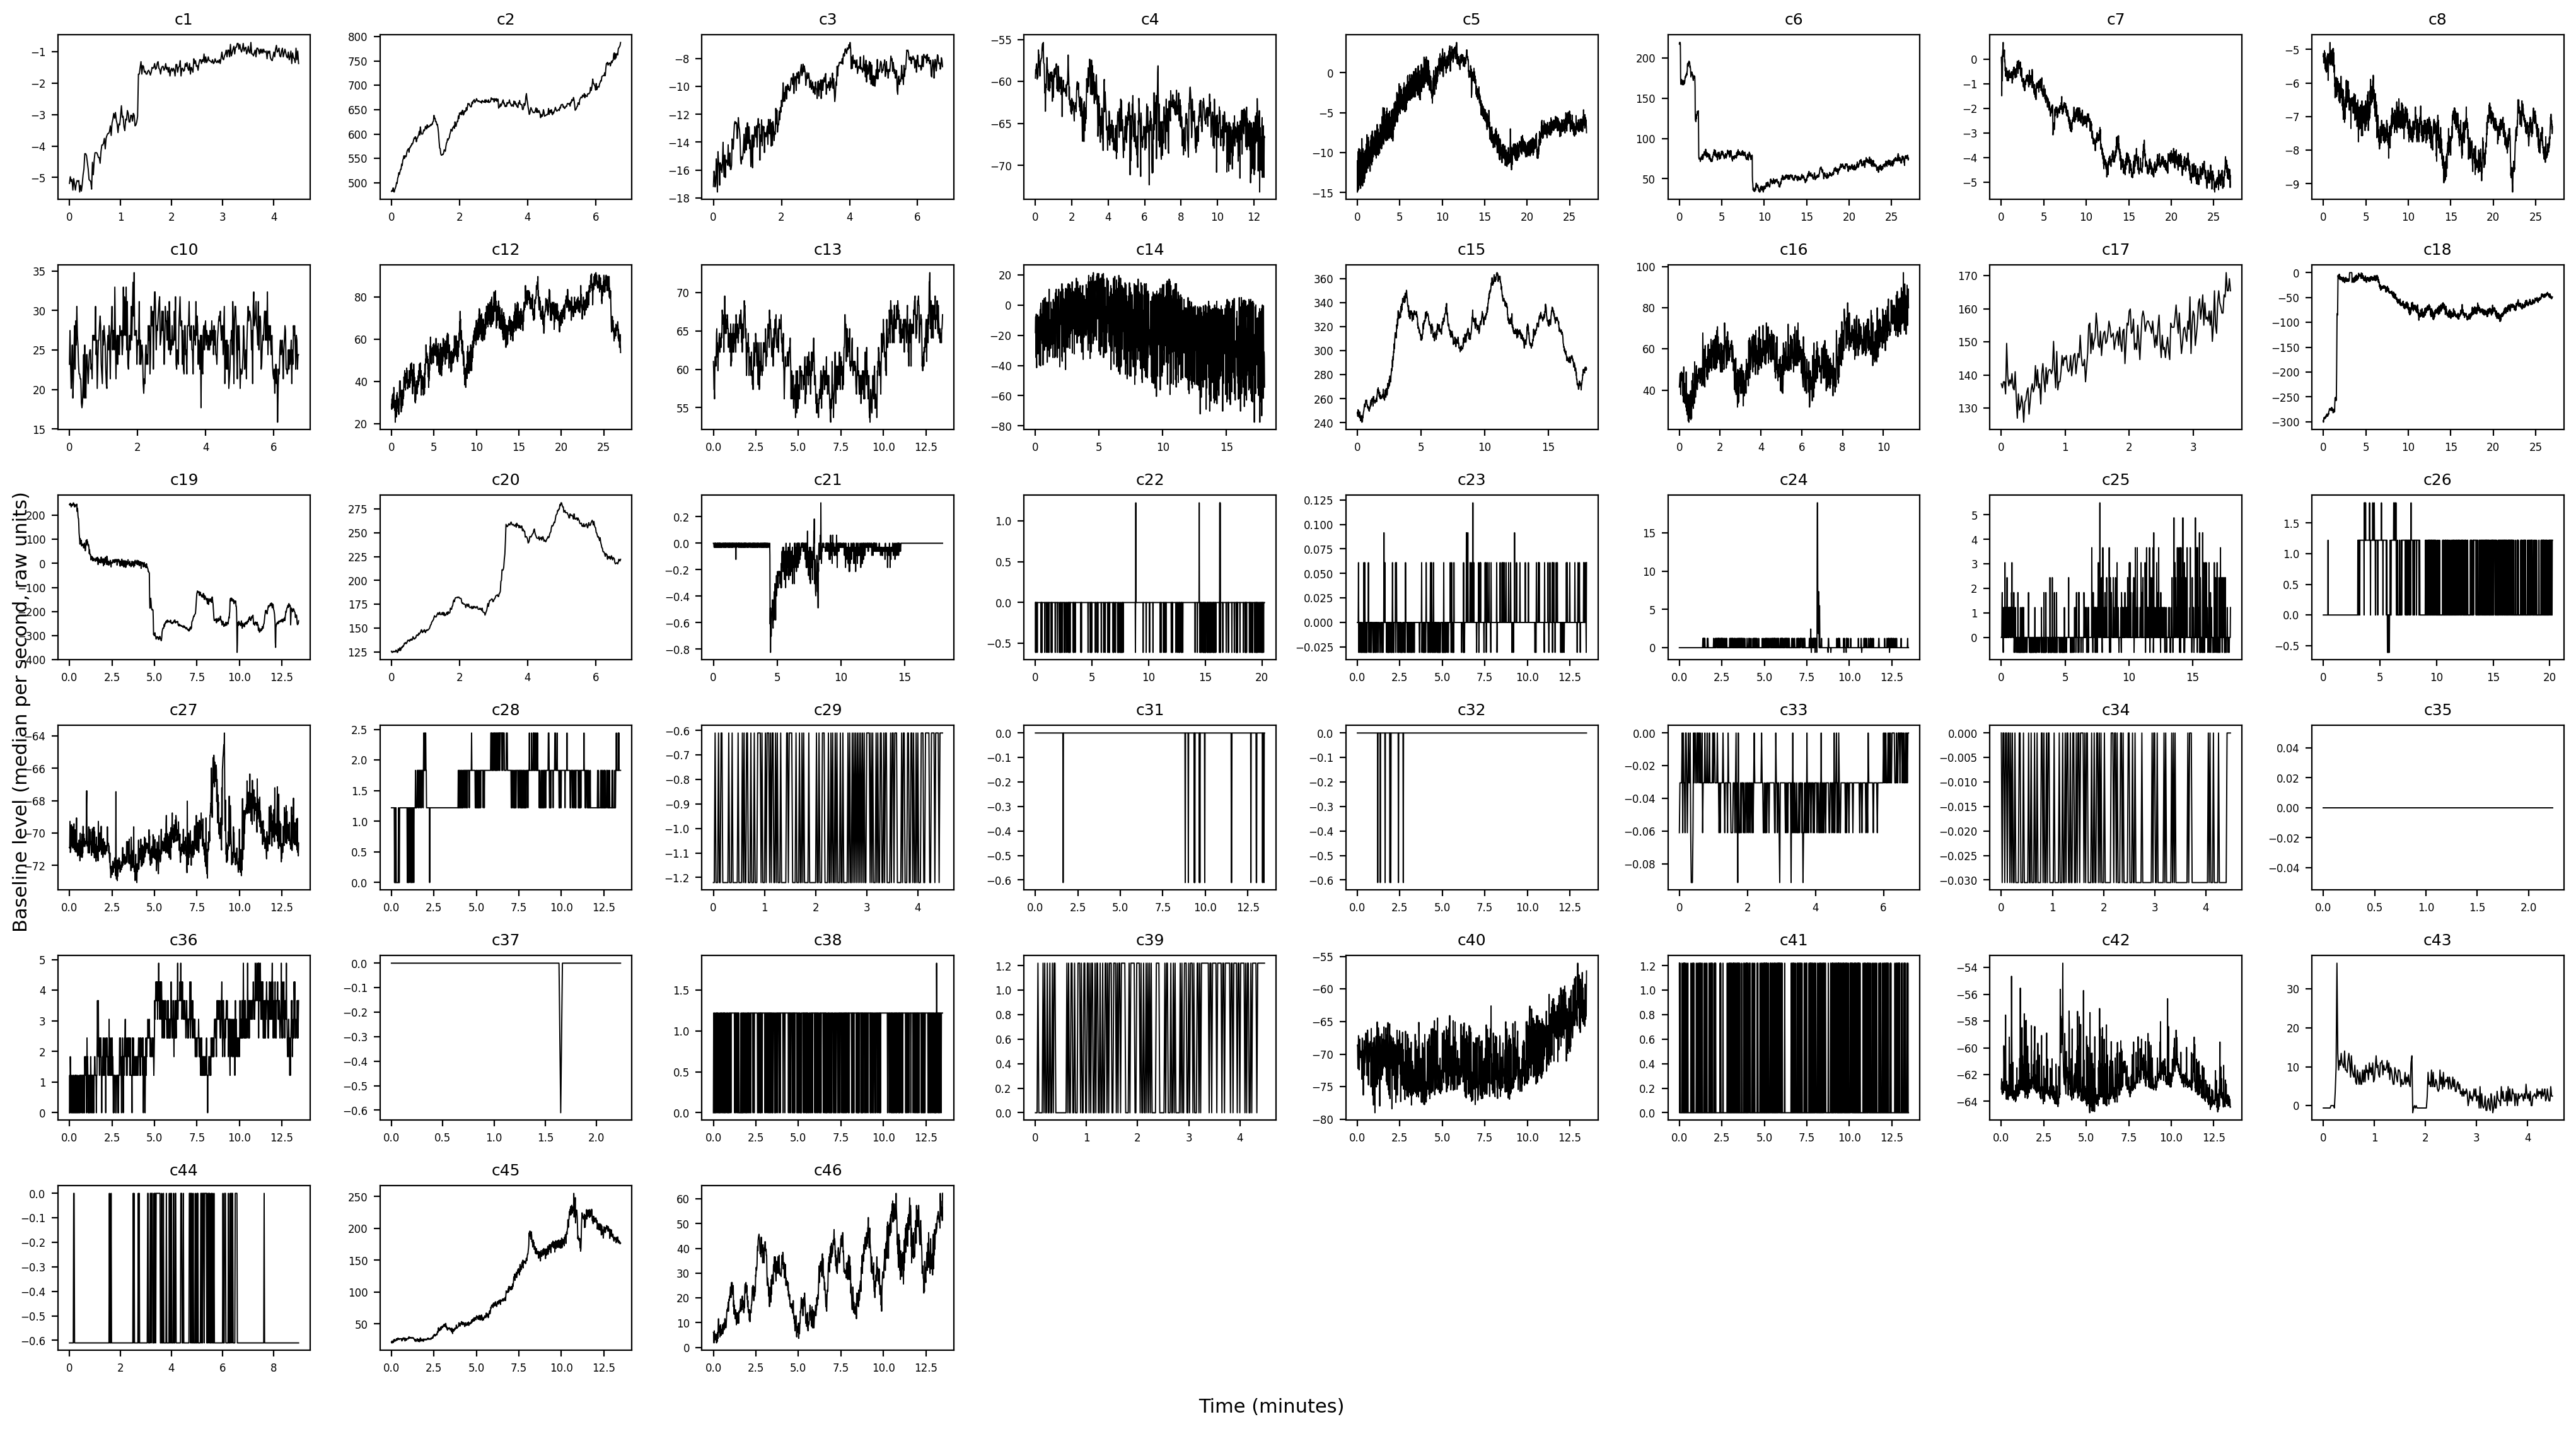

In [3]:
n = len(cell_nums)
ncols = 8
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.6, nrows * 1.9))
axes = axes.flatten()

for ax, cell_num in zip(axes, cell_nums):
    t_min, baseline = baselines[cell_num]
    ax.plot(t_min, baseline, color='black', lw=0.7)
    ax.set_title(f'c{cell_num}', fontsize=9)
    ax.tick_params(labelsize=6)

for ax in axes[n:]:
    ax.axis('off')

fig.supxlabel('Time (minutes)', fontsize=11)
fig.supylabel('Baseline level (median per second, raw units)', fontsize=11)
plt.tight_layout()
plt.show()

### Finding jumps automatically, instead of scanning 43 plots by eye

For each cell's baseline line above: take the step-to-step change from one second to the next, everywhere in the recording. Most of those steps are just normal wiggle. Find the single **biggest** step, and compare it to the **typical** step size for that same cell (the median of all the steps) - `jump_ratio = biggest step / typical step`. A cell whose biggest jump is, say, 20x its normal wiggle has something real going on; a cell where the biggest jump is only 2-3x normal is just noise. Sorted below, biggest ratio first.

In [4]:
import pandas as pd

rows = []
for cell_num in cell_nums:
    t_min, baseline = baselines[cell_num]
    steps = np.abs(np.diff(baseline))
    typical_step = np.median(steps)
    biggest_step = steps.max()
    biggest_step_time_min = t_min[np.argmax(steps)]
    jump_ratio = biggest_step / (typical_step + 1e-12)
    rows.append({
        'cell_id': f'c{cell_num}',
        'biggest_jump': biggest_step,
        'typical_step': typical_step,
        'jump_ratio': jump_ratio,
        'jump_at_minute': biggest_step_time_min,
    })

jump_df = pd.DataFrame(rows).sort_values('jump_ratio', ascending=False).reset_index(drop=True)
jump_df.round(3)

,cell_id,biggest_jump,typical_step,jump_ratio,jump_at_minute
0,c24,18.921,0.000,1.892090e+13,8.100
1,c38,1.831,0.000,1.831055e+12,13.117
2,c22,1.831,0.000,1.831055e+12,16.283
3,c26,1.831,0.000,1.831055e+12,3.600
4,c28,1.221,0.000,1.220703e+12,0.167
5,c41,1.221,0.000,1.220703e+12,0.000
6,c39,1.221,0.000,1.220703e+12,0.033
7,c31,0.610,0.000,6.103515e+11,1.617
8,c32,0.610,0.000,6.103515e+11,1.183
9,c37,0.610,0.000,6.103515e+11,1.633


### Looking at every cell's flagged jump, not just a few by hand

For every cell where `typical_step` was a real (non-zero) number, zoom into +/-5 seconds of the raw trace around that cell's flagged jump time, the same way as the manual check above - just done for all of them instead of 3. Cells where `typical_step` was 0 (listed at the top of the table above) are skipped here - their ratio was a divide-by-near-zero artifact, not a real measurement, so there's nothing meaningful to zoom into for those from this method.

29 / 43 cells have a meaningful (non-degenerate) jump_ratio; zooming into each of their flagged jump times below.


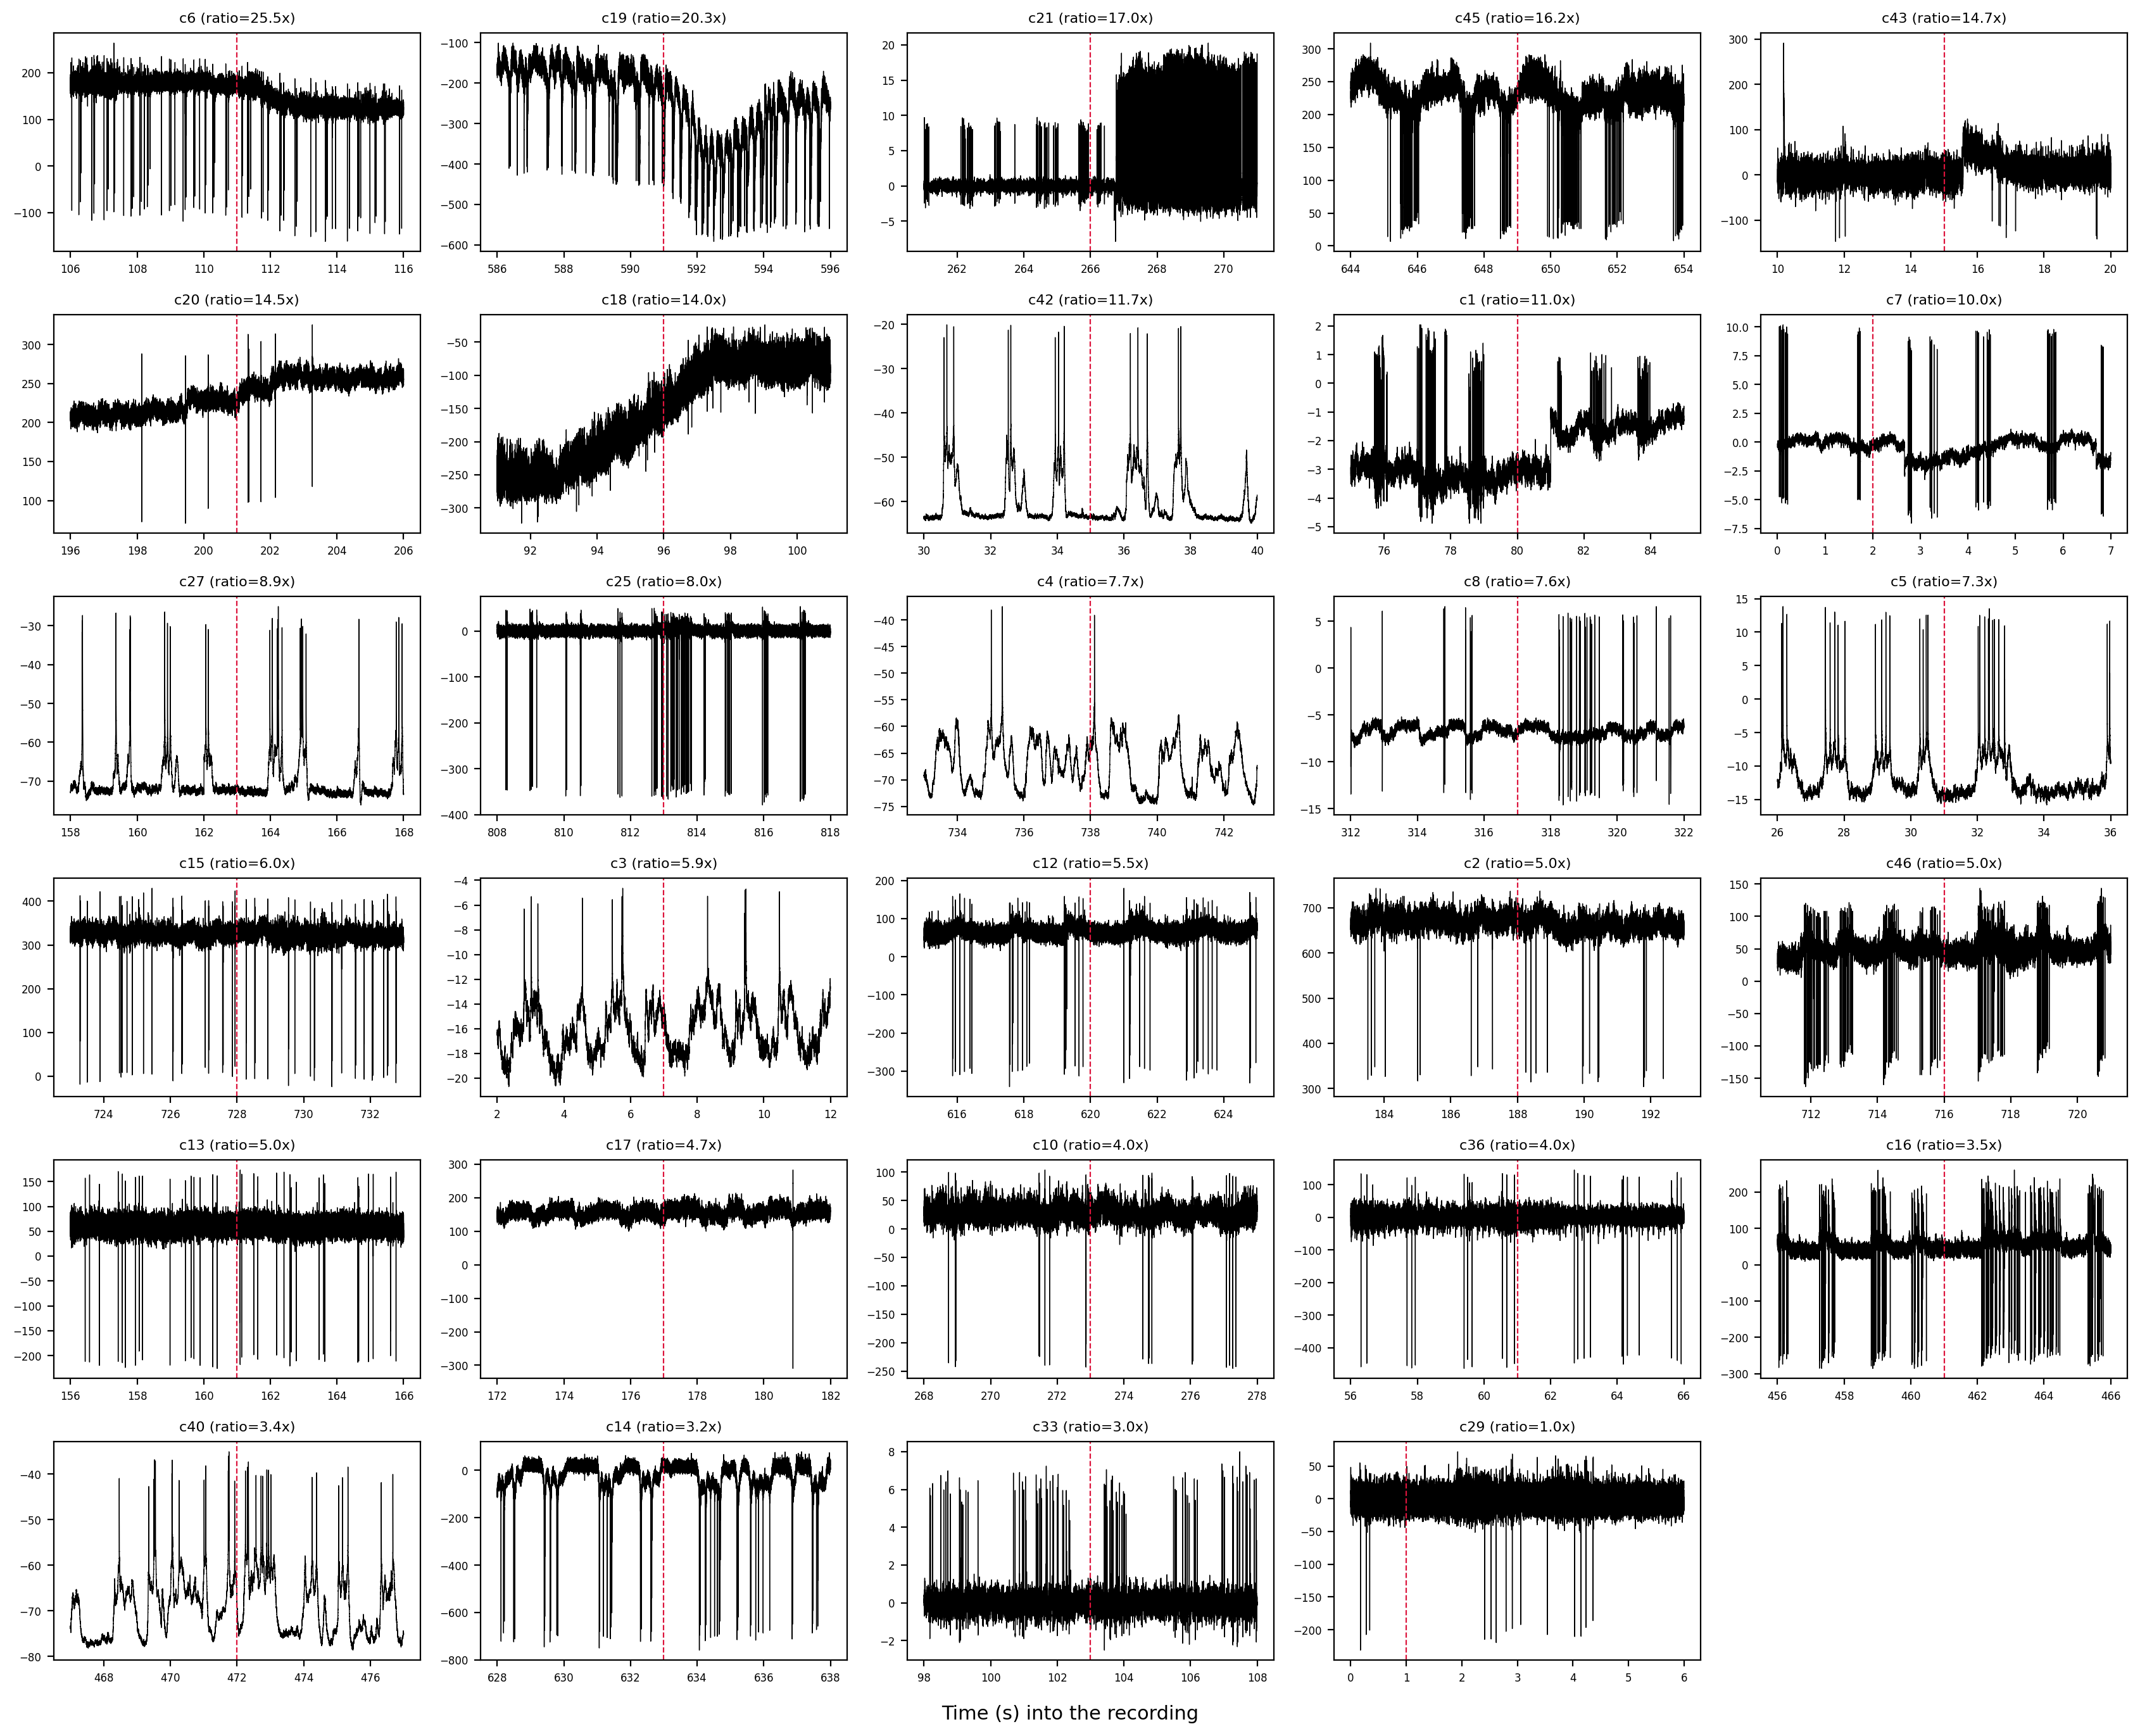

In [5]:
valid_jumps = jump_df[jump_df['typical_step'] > 1e-9].reset_index(drop=True)
print(f'{len(valid_jumps)} / {len(jump_df)} cells have a meaningful (non-degenerate) jump_ratio; '
      f'zooming into each of their flagged jump times below.')

ncols = 5
nrows = int(np.ceil(len(valid_jumps) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.4, nrows * 2.3))
axes = axes.flatten()

for ax, row in zip(axes, valid_jumps.itertuples()):
    cell_num = int(row.cell_id[1:])
    fs = config.DICT_PATCH_FS[cell_num]
    trace, _ = load_raw_patch(cell_num)
    t_center = row.jump_at_minute * 60
    i0 = max(0, int((t_center - 5) * fs))
    i1 = min(len(trace), int((t_center + 5) * fs))
    seg = trace[i0:i1]
    t = (np.arange(len(seg)) + i0) / fs
    ax.plot(t, seg, color='black', lw=0.5)
    ax.axvline(t_center, color='crimson', ls='--', lw=0.8)
    ax.set_title(f'{row.cell_id} (ratio={row.jump_ratio:.1f}x)', fontsize=8)
    ax.tick_params(labelsize=6)

for ax in axes[len(valid_jumps):]:
    ax.axis('off')

fig.supxlabel('Time (s) into the recording', fontsize=11)
plt.tight_layout()
plt.show()

### Cells with a visible change at their flagged jump

Of the 29 cells above, most show nothing notable - the flagged "jump" was just an ordinary large spike. A handful show a real, visible change in the trace right at that point. Shown larger below, with what kind of change it looks like. This doesn't say *why* it happens (real physiology and an imperfect current step can look similar here) - it's just an honest visual flag of where something changes.

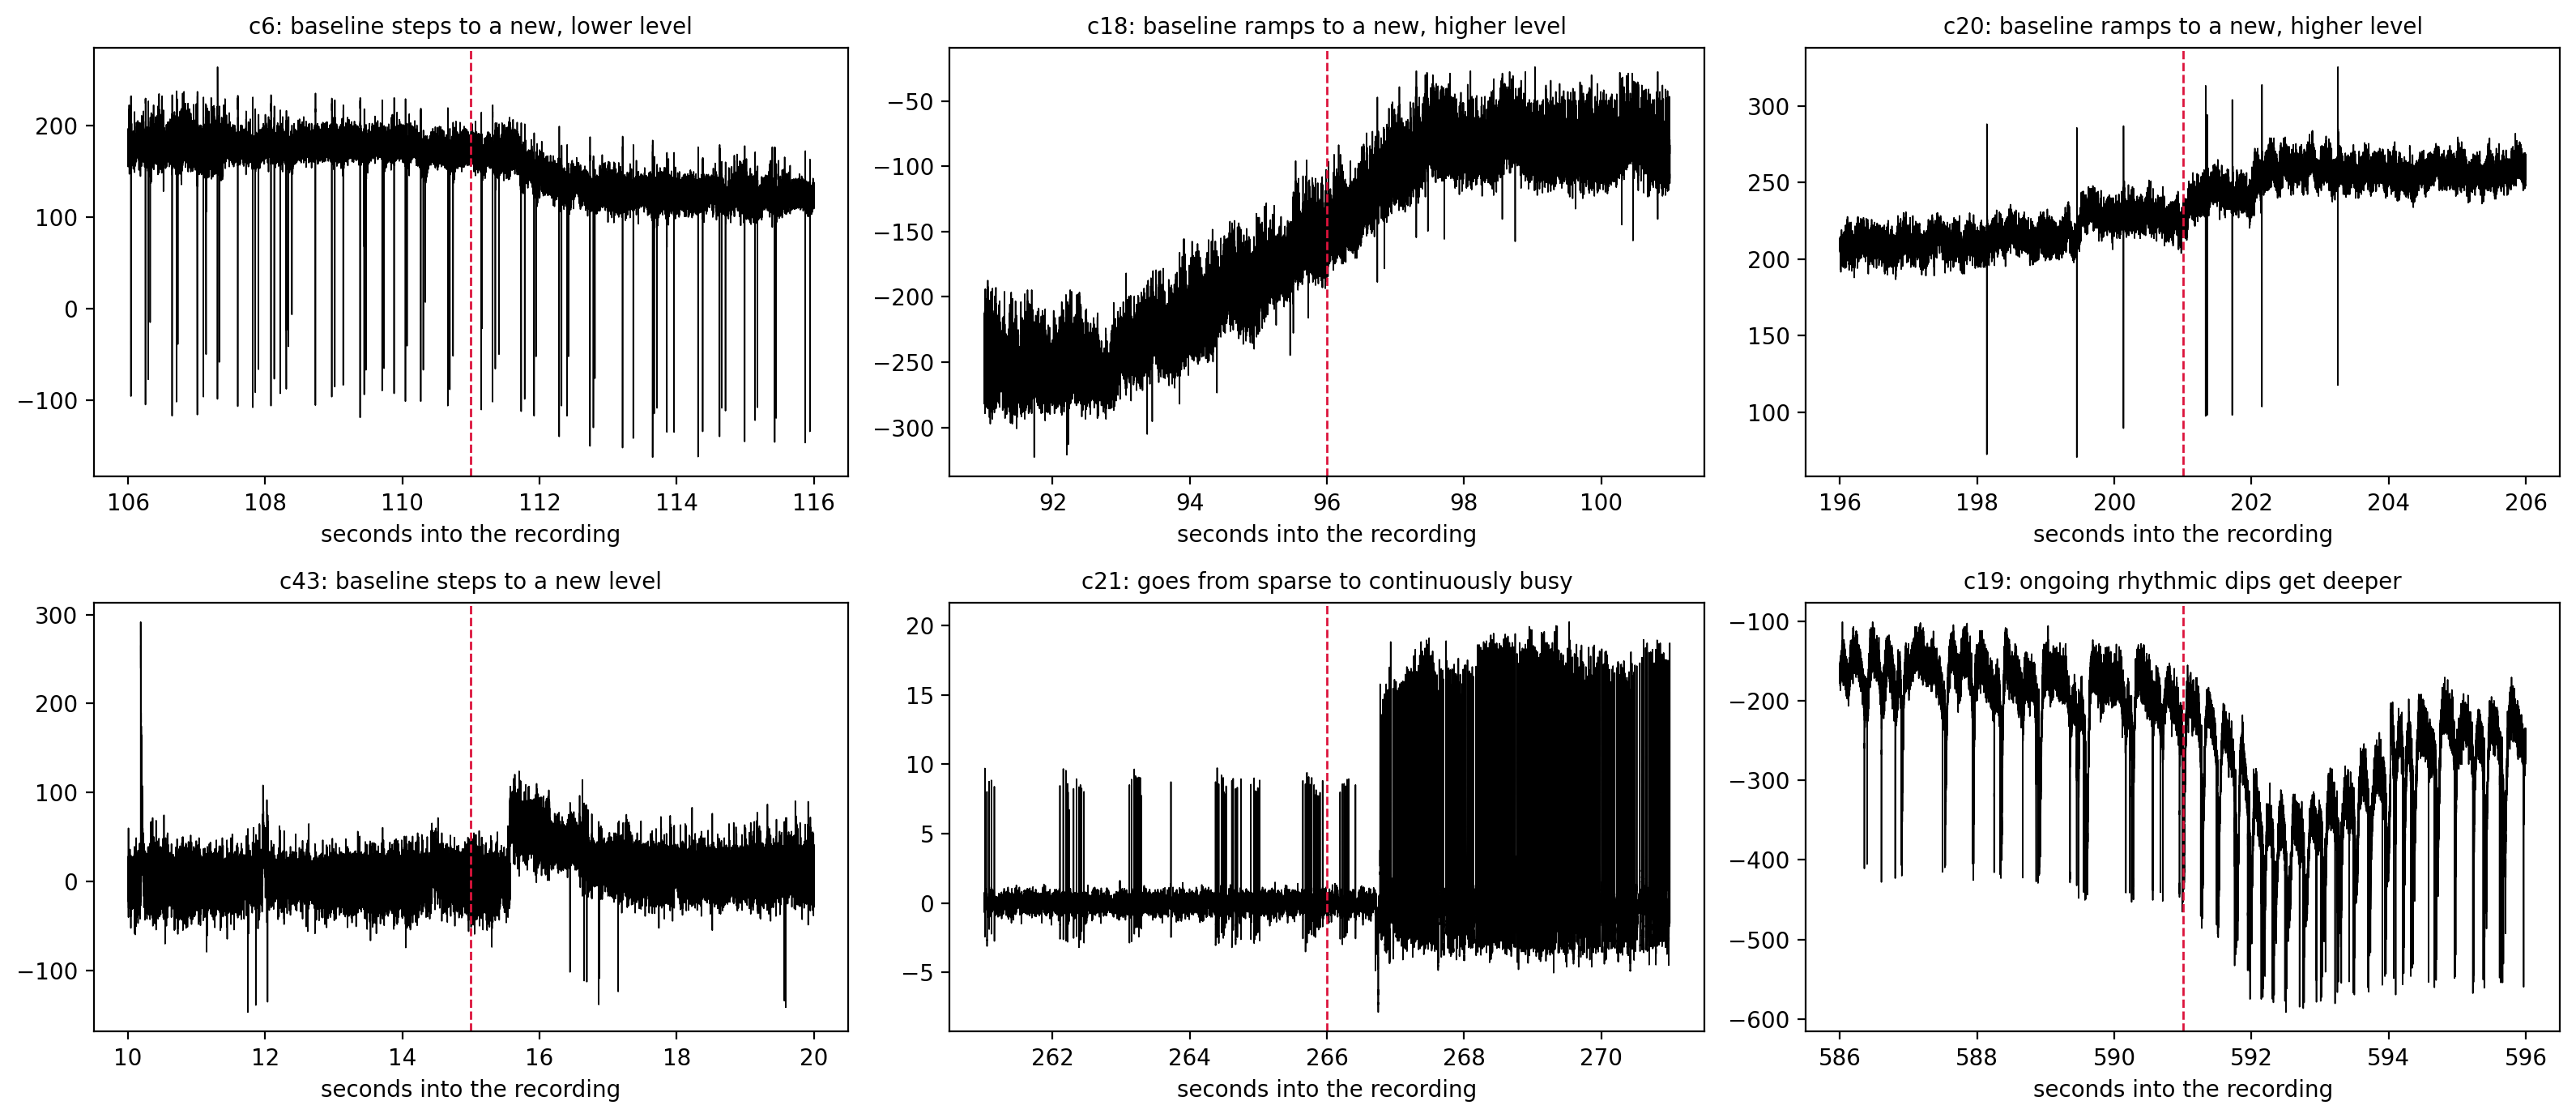

In [6]:
notable = [
    ('c6',  'baseline steps to a new, lower level'),
    ('c18', 'baseline ramps to a new, higher level'),
    ('c20', 'baseline ramps to a new, higher level'),
    ('c43', 'baseline steps to a new level'),
    ('c21', 'goes from sparse to continuously busy'),
    ('c19', 'ongoing rhythmic dips get deeper'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.flatten()

for ax, (cid_str, description) in zip(axes, notable):
    cell_num = int(cid_str[1:])
    fs = config.DICT_PATCH_FS[cell_num]
    trace, _ = load_raw_patch(cell_num)
    row = jump_df[jump_df['cell_id'] == cid_str].iloc[0]
    t_center = row['jump_at_minute'] * 60
    i0 = max(0, int((t_center - 5) * fs))
    i1 = min(len(trace), int((t_center + 5) * fs))
    seg = trace[i0:i1]
    t = (np.arange(len(seg)) + i0) / fs
    ax.plot(t, seg, color='black', lw=0.6)
    ax.axvline(t_center, color='crimson', ls='--', lw=1)
    ax.set_title(f'{cid_str}: {description}', fontsize=10)
    ax.set_xlabel('seconds into the recording')

plt.tight_layout()
plt.show()

**Worth noting:** all six changes above happen very early - c43 at 15s, c18 at 96s, c6 at 111s, c20 at 201s, c21 at 266s, c19 at 591s (under 10 minutes into every recording, most under 5). That timing matches the settling-in period every patch recording has right after the electrode first seals onto the cell, not something occurring at an arbitrary point later in the recording - which is what a stimulus deliberately timed to rescue a quiet cell mid-recording would look like instead.

## 2. Zoom in on the raw trace for one cell

Set `CELL_TO_INSPECT` below and re-run - shows a few short raw-trace snippets spread across the recording (start / one-third / two-thirds / near the end), so you can look by eye for brief transient blips (Ashley's "tiny capacitance transients") anywhere in the trace, not just in the baseline summary above.

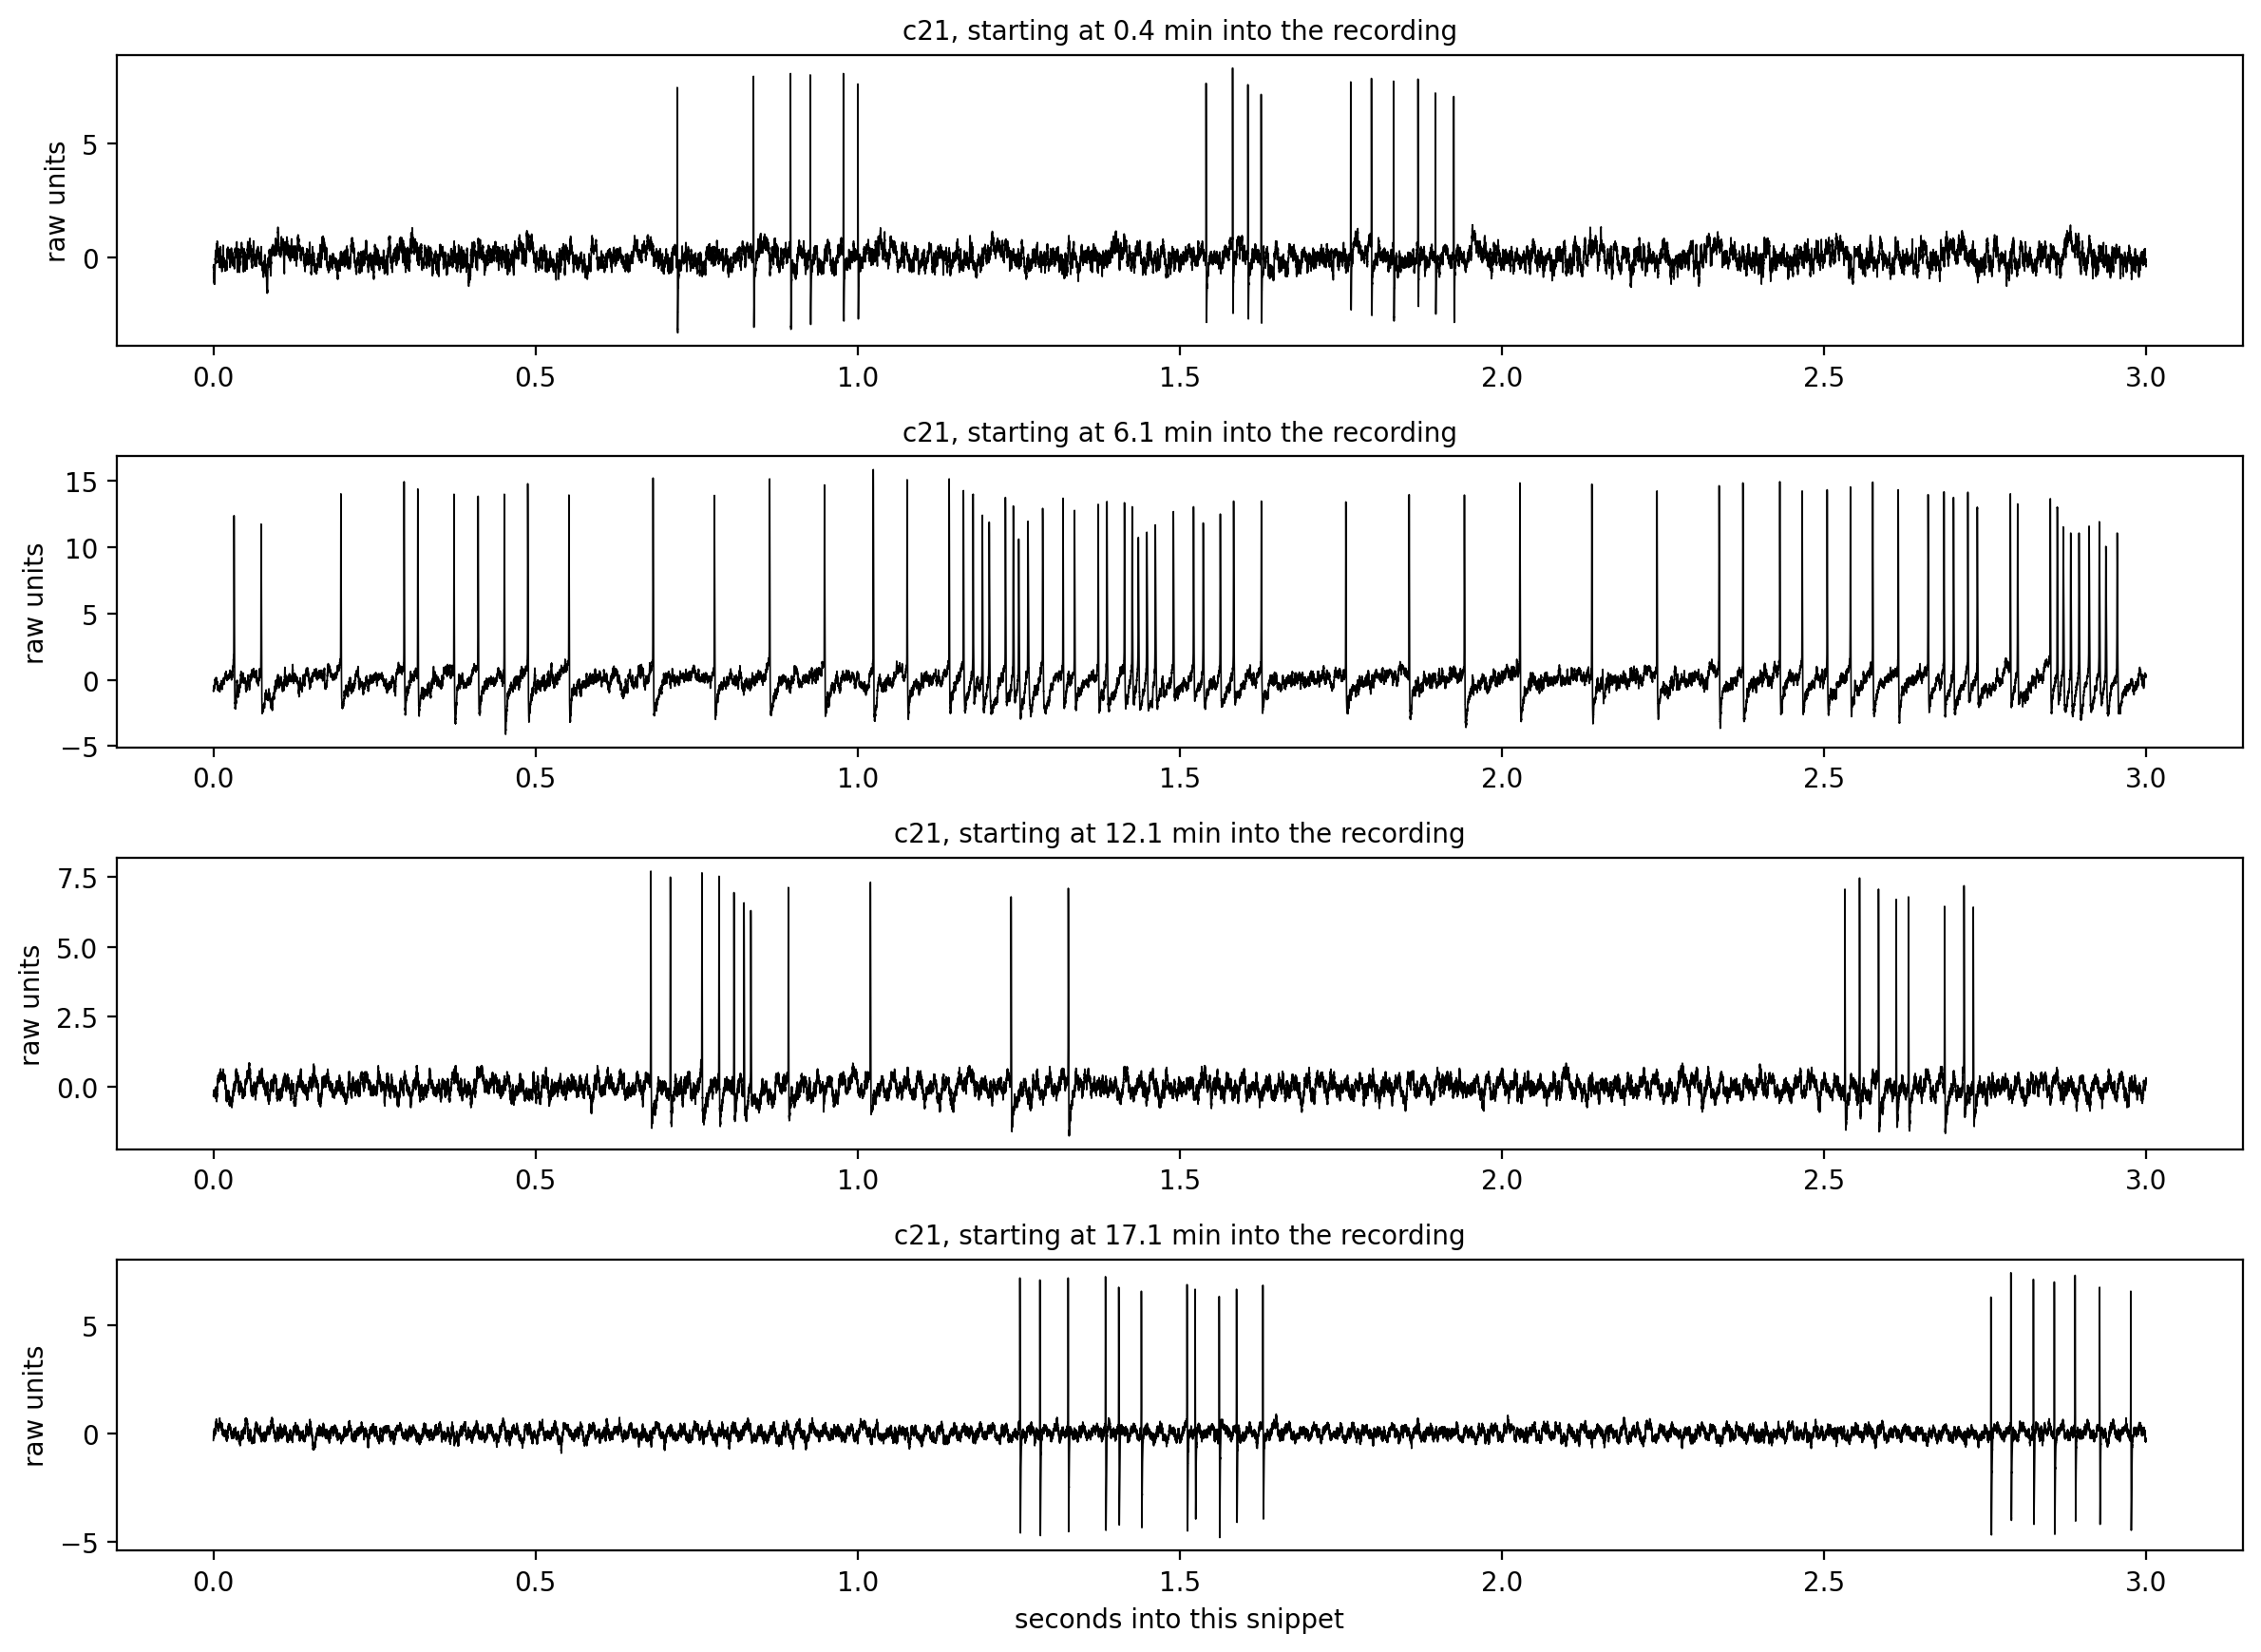

In [7]:
CELL_TO_INSPECT = 21   # change this to any cell number and re-run
SNIPPET_SECONDS = 3

trace, fs = load_raw_patch(CELL_TO_INSPECT)
duration_s = len(trace) / fs
snippet_starts = [duration_s * frac for frac in (0.02, 0.34, 0.67, 0.95)]

fig, axes = plt.subplots(len(snippet_starts), 1, figsize=(12, 2.2 * len(snippet_starts)), sharey=False)
for ax, t0 in zip(axes, snippet_starts):
    i0 = int(t0 * fs)
    i1 = i0 + int(SNIPPET_SECONDS * fs)
    seg = trace[i0:i1]
    t = np.arange(len(seg)) / fs
    ax.plot(t, seg, color='black', lw=0.6)
    ax.set_title(f'c{CELL_TO_INSPECT}, starting at {t0/60:.1f} min into the recording', fontsize=10)
    ax.set_ylabel('raw units')
axes[-1].set_xlabel('seconds into this snippet')
plt.tight_layout()
plt.show()

---
**Data used:** raw, unfiltered `c{N}_patch_ch1.bin` recordings for all 43 spe-1 cells, obtained from the lab's original recording archive and placed in `raw_patch_recordings/` alongside the existing `filt_patch_recordings/` used elsewhere in the pipeline. These are the true pre-processing recordings - no bandpass filter has been applied, so a real sustained shift in resting level would appear directly, rather than as the brief filtered echo a shift becomes after the 10 Hz highpass used everywhere else in the paper.